In [2]:
import pandas as pd

df_1 = pd.read_csv('tienda_1.csv')
df_2 = pd.read_csv('tienda_2.csv')
df_3 = pd.read_csv('tienda_3.csv')
df_4 = pd.read_csv('tienda_4.csv')

df_1['Tienda'] = 'Tienda 1'
df_2['Tienda'] = 'Tienda 2'
df_3['Tienda'] = 'Tienda 3'
df_4['Tienda'] = 'Tienda 4'

df_tiendas = pd.concat([df_1, df_2, df_3, df_4], ignore_index=True)

print("¡Éxito! Datos cargados.")
df_tiendas.head()

¡Éxito! Datos cargados.


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1


### 1. Análisis de facturación


In [4]:
# Agrupamos los datos por tienda y sumamos los precios para obtener la facturación total
facturacion_por_tienda = df_tiendas.groupby('Tienda')['Precio'].sum().sort_values(ascending=False)

# Mostramos el resultado numérico
print("Facturación por tienda:")
display(facturacion_por_tienda)

Facturación por tienda:


,Precio
Tienda,
Tienda 1,1.150880e+09
Tienda 2,1.116344e+09
Tienda 3,1.098020e+09
Tienda 4,1.038376e+09


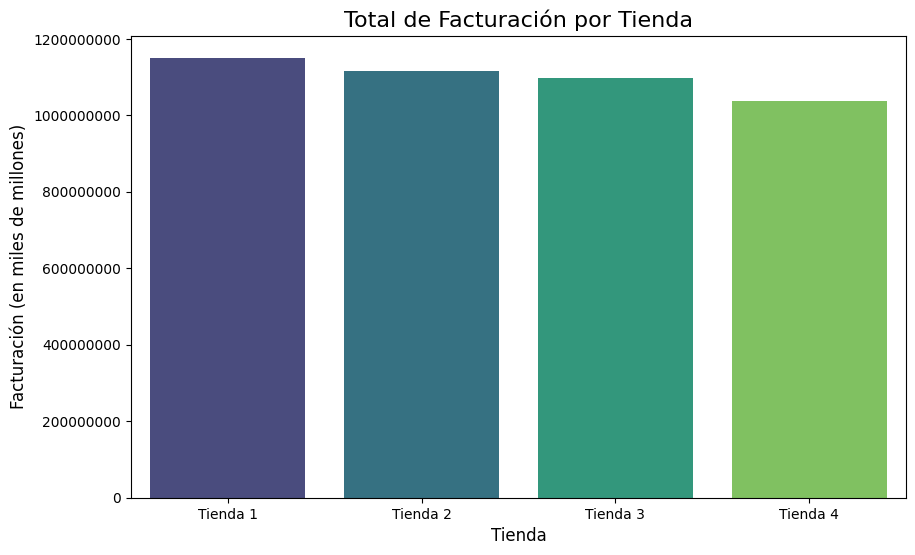

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x=facturacion_por_tienda.index,
    y=facturacion_por_tienda.values,
    hue=facturacion_por_tienda.index,
    legend=False,
    palette="viridis"
)

plt.title('Total de Facturación por Tienda', fontsize=16)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Facturación (en miles de millones)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

**Conclusión:**
 La Tienda 1 lidera los ingresos totales, consolidándose como la sucursal más fuerte en ventas brutas.

### 2. Ventas por categoría


In [9]:
# Contamos la cantidad de ventas por cada categoría
ventas_por_categoria = df_tiendas['Categoría del Producto'].value_counts()

print("Cantidad de ventas por categoría:")
display(ventas_por_categoria)

Cantidad de ventas por categoría:


,count
Categoría del Producto,
Muebles,1886
Electrónicos,1772
Juguetes,1290
Electrodomésticos,1149
Deportes y diversión,1113
Instrumentos musicales,753
Libros,742
Artículos para el hogar,730


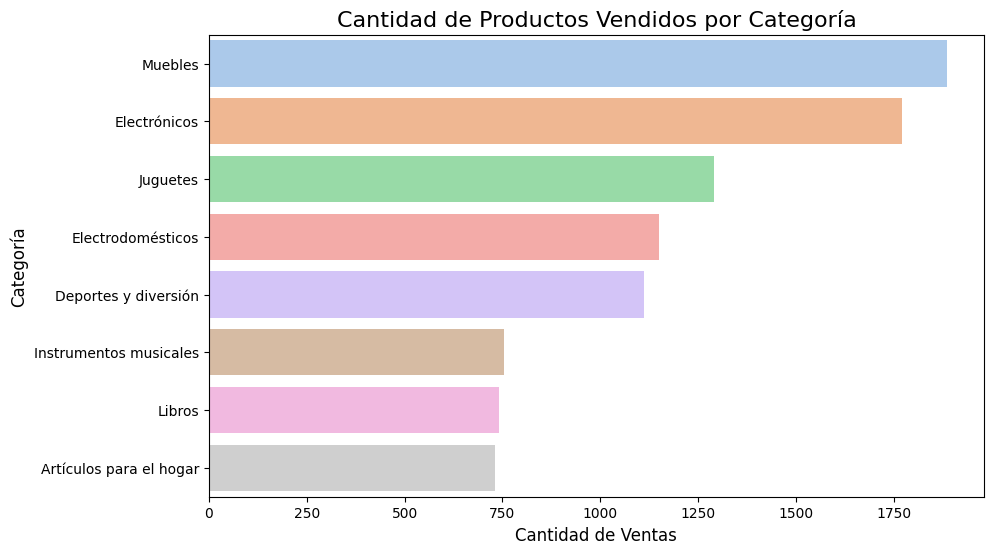

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x=ventas_por_categoria.values,
    y=ventas_por_categoria.index,
    hue=ventas_por_categoria.index,
    legend=False,
    palette="pastel"
)

plt.title('Cantidad de Productos Vendidos por Categoría', fontsize=16)
plt.xlabel('Cantidad de Ventas', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

plt.show()

**Conclusión:** Las categorías de Muebles y Electrónicos dominan el mercado y sostienen el volumen principal del negocio.

### 3. Calificación promedio de la tienda


In [11]:
# Agrupamos por tienda y calculamos el promedio de la columna 'Calificación'
calificacion_promedio = df_tiendas.groupby('Tienda')['Calificación'].mean().sort_values(ascending=False)

# Mostramos el ranking de satisfacción
print("Ranking de Calificación Promedio (1 a 5 estrellas):")
display(calificacion_promedio)

Ranking de Calificación Promedio (1 a 5 estrellas):


,Calificación
Tienda,
Tienda 3,4.048326
Tienda 2,4.037304
Tienda 4,3.995759
Tienda 1,3.976685


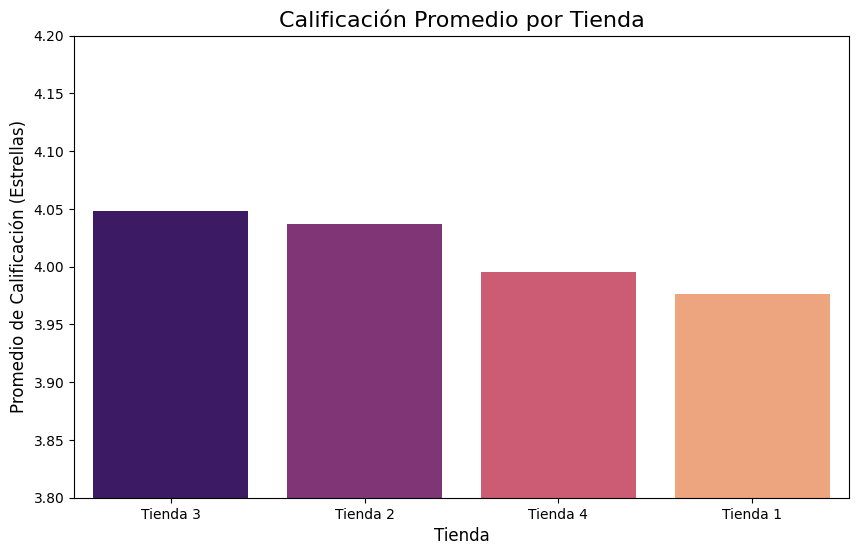

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x=calificacion_promedio.index,
    y=calificacion_promedio.values,
    hue=calificacion_promedio.index,
    legend=False,
    palette="magma"
)

plt.title('Calificación Promedio por Tienda', fontsize=16)
plt.ylabel('Promedio de Calificación (Estrellas)', fontsize=12)
plt.xlabel('Tienda', fontsize=12)
plt.ylim(3.8, 4.2)

plt.show()

**Conclusión:** La Tienda 1 tiene la peor satisfacción al cliente a pesar de sus altas ventas, mientras que la Tienda 3 es la mejor valorada.

### 4. Productos más y menos vendidos


In [15]:
conteo_productos = df_tiendas['Producto'].value_counts()

top_5_productos = conteo_productos.head(5)
bottom_5_productos = conteo_productos.tail(5)

print("TOP 5 PRODUCTOS MÁS VENDIDOS:")
display(top_5_productos)

print("\nTOP 5 PRODUCTOS MENOS VENDIDOS:")
display(bottom_5_productos)

TOP 5 PRODUCTOS MÁS VENDIDOS:


,count
Producto,
Mesa de noche,210
Carrito de control remoto,206
Microondas,206
Batería,203
Cama king,201



TOP 5 PRODUCTOS MENOS VENDIDOS:


,count
Producto,
Ciencia de datos con Python,166
Guitarra eléctrica,165
Mochila,163
Auriculares con micrófono,158
Celular ABXY,157


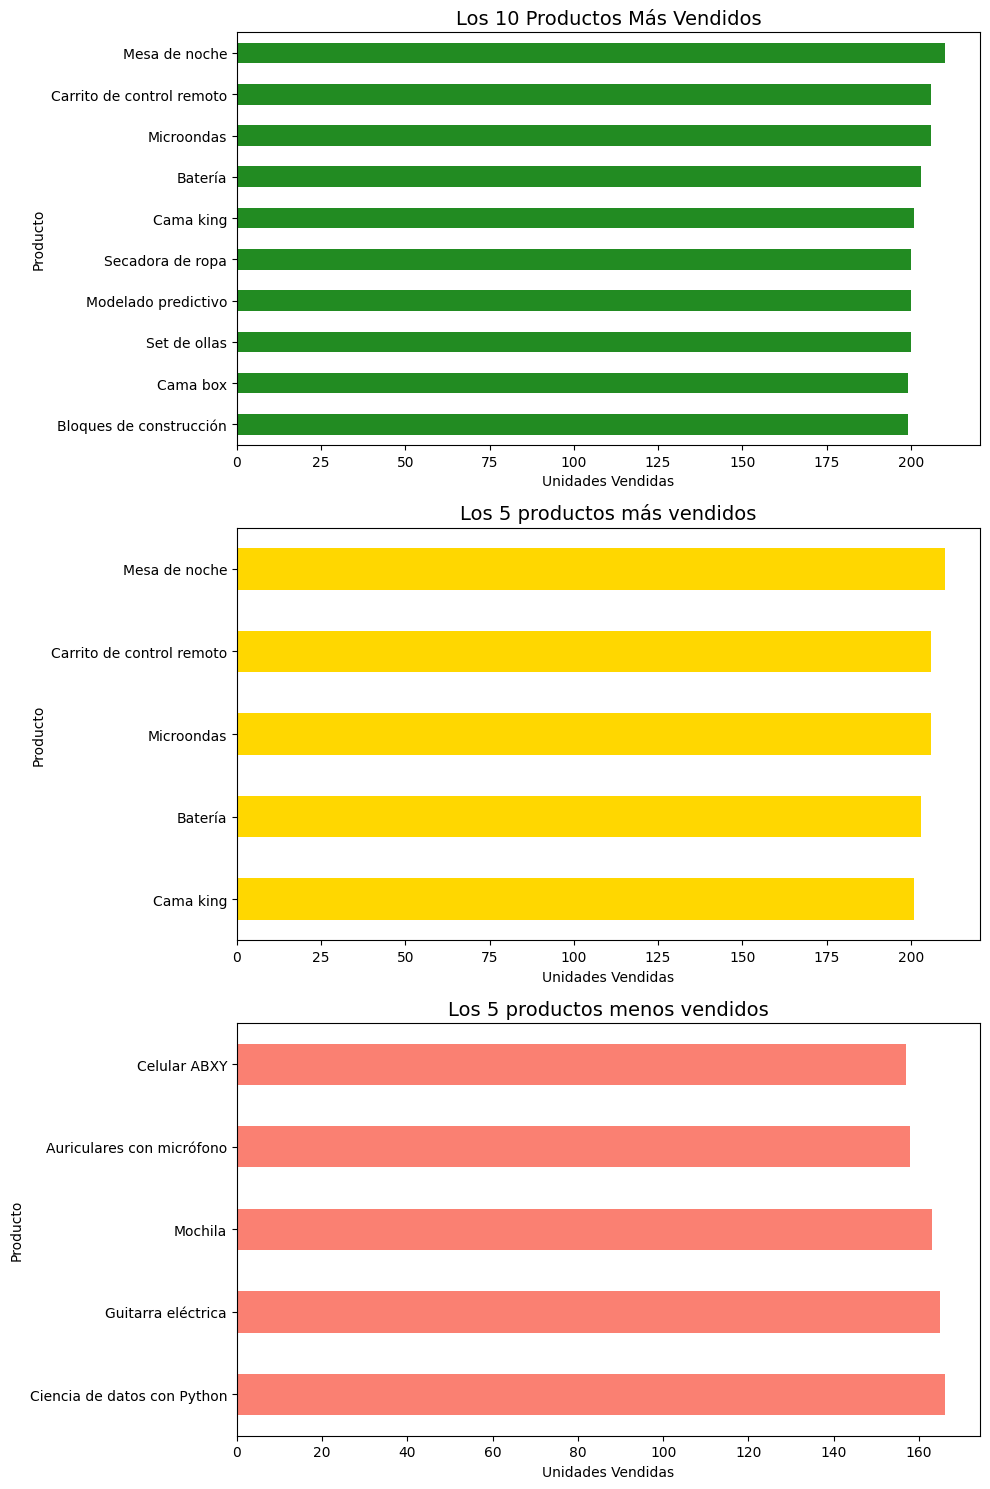

In [19]:
import matplotlib.pyplot as plt

top_10 = conteo_productos.head(10)
top_5 = conteo_productos.head(5)
bottom_5 = conteo_productos.tail(5)

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# GRÁFICO 1: TOP 10
top_10.plot(kind='barh', color='forestgreen', ax=axes[0])
axes[0].set_title('Los 10 Productos Más Vendidos', fontsize=14)
axes[0].set_xlabel('Unidades Vendidas')
axes[0].invert_yaxis()

# GRÁFICO 2: TOP 5 (Los Líderes)
top_5.plot(kind='barh', color='gold', ax=axes[1])
axes[1].set_title('Los 5 productos más vendidos', fontsize=14)
axes[1].set_xlabel('Unidades Vendidas')
axes[1].invert_yaxis()

# GRÁFICO 3: BOTTOM 5 (Los Menos Vendidos)
bottom_5.plot(kind='barh', color='salmon', ax=axes[2])
axes[2].set_title('Los 5 productos menos vendidos', fontsize=14)
axes[2].set_xlabel('Unidades Vendidas')

plt.tight_layout()
plt.show()

**Conclusión:** La Mesa de noche es el producto estrella indispensable, mientras que el "Celular ABXY" tiene la menor rotación.

### 5. Envío promedio por tienda


In [21]:
# Agrupamos por tienda y calculamos el promedio de la columna 'Costo de envío'
envio_promedio = df_tiendas.groupby('Tienda')['Costo de envío'].mean().sort_values(ascending=False)
print("Costo de envío promedio por tienda:")
display(envio_promedio)

Costo de envío promedio por tienda:


,Costo de envío
Tienda,
Tienda 1,26018.609580
Tienda 2,25216.235693
Tienda 3,24805.680373
Tienda 4,23459.457167


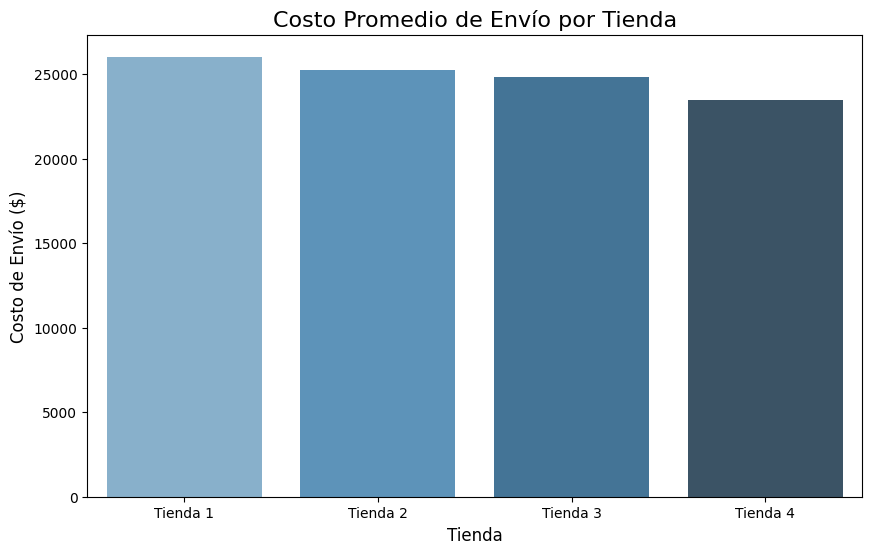

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x=envio_promedio.index,
    y=envio_promedio.values,
    hue=envio_promedio.index,
    legend=False,
    palette="Blues_d"
)

plt.title('Costo Promedio de Envío por Tienda', fontsize=16)
plt.ylabel('Costo de Envío ($)', fontsize=12)
plt.xlabel('Tienda', fontsize=12)

plt.show()

**Conclusión:** La Tienda 1 necesita optimizar su logística urgentemente. Los clientes compran mucho, pero el costo de envío los deja insatisfechos"